In [1]:
import os # For directory and file operations
import numpy as np # For numerical operations and handling image arrays
import pandas # For generating random values for augmenataion
from PIL import Image, ImageEnhance # For image processing and enhancement

# keras
from tensorflow.keras.models import Sequential # for building the model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout # for model layers
from tensorflow.keras.preprocessing.image import load_img # for loading images
from tensorflow.keras.optimizers import Adam # for optimizer
from tensorflow.keras.applications import VGG16 # for using VGG16 model
from sklearn.utils import shuffle # for shuffling the data

In [2]:
# Directories for training and testing data
train_dir = 'MRI Images/training'
test_dir = 'MRI Images/testing'

#load and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)
train_paths, train_labels = shuffle(train_paths, train_labels)

#load and shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)
test_paths, test_labels = shuffle(test_paths, test_labels)

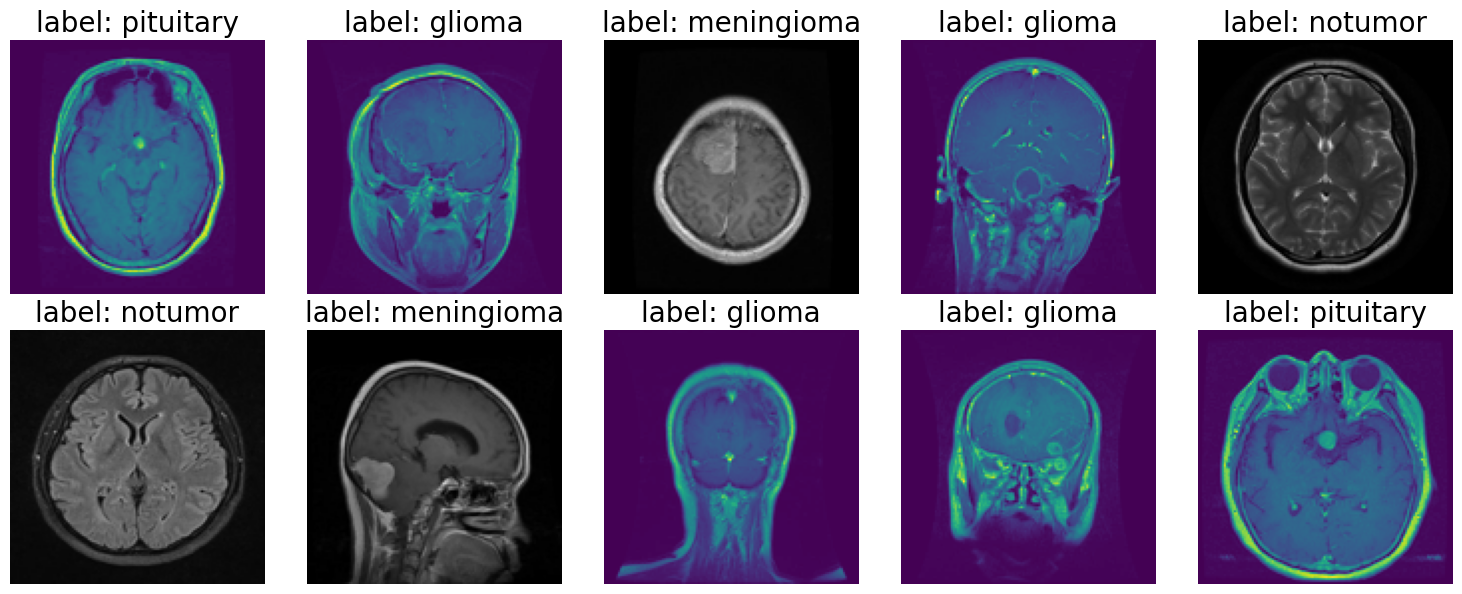

In [3]:
import random 
import matplotlib.pyplot as plt

# select random indices for 10 images
random_indices = random.sample(range(len(train_paths)),10)


# create a figure to display images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# loops through the random indices and display images
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128, 128))

    #display images
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"label: {train_labels[idx]}", fontsize=20)
plt.tight_layout()
plt.show()

In [6]:
# For TRAINING - includes random augmentation
import random
from PIL import ImageEnhance

def augment_image(img):
    # Random horizontal flip
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Random brightness
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))

    # Random contrast
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))

    # Normalize to [0,1]
    img = np.array(img) / 255.0
    return img
def open_images(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = augment_image(img)
        images.append(img)
    return np.array(images)

# For TEST/EVAL/INFERENCE - no augmentation, just normalize
def load_images_clean(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = np.array(img) / 255.0
        images.append(img)
    return np.array(images)

# Compute this ONCE, not inside the generator/encode function
unique_labels = sorted(os.listdir(train_dir))

# Encode labels (convert label names to integers)
def encode_label(labels):
    encoded = [unique_labels.index(label) for label in labels]
    return encoded

# Data generator for batching
def datagen(paths, labels, batch_size=12):
    while True:  # loop forever - model.fit controls epochs/steps, not this function
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, np.array(batch_labels)

In [7]:
# Model Architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# set only the last few layers
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# build Model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))) # INPUT LAYER
model.add(base_model) # VGG16 model
model.add(Flatten()) # flatten layer
model.add(Dropout(0.3)) # dropuout layer-- overfitting se bachanae ke liye (random 30% nuiance)

model.add(Dense(128, activation='relu')) #dense layer
model.add(Dropout(0.2)) # dropuout layer-- overfitting se bachanae ke liye (random 20% nuiance)

model.add(Dense(len(os.listdir(train_dir)),activation='softmax')) # multi class classification me always use softmax as activation


#compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

#parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

#train model
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size),
    steps_per_epoch=steps,
    epochs=epochs
)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 204s 721ms/step - loss: 0.4685 - sparse_categorical_accuracy: 0.8157
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 185s 660ms/step - loss: 0.2460 - sparse_categorical_accuracy: 0.9093
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 187s 668ms/step - loss: 0.1748 - sparse_categorical_accuracy: 0.9341
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 186s 664ms/step - loss: 0.1315 - sparse_categorical_accuracy: 0.9514
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 188s 671ms/step - loss: 0.1001 - sparse_categorical_accuracy: 0.9616


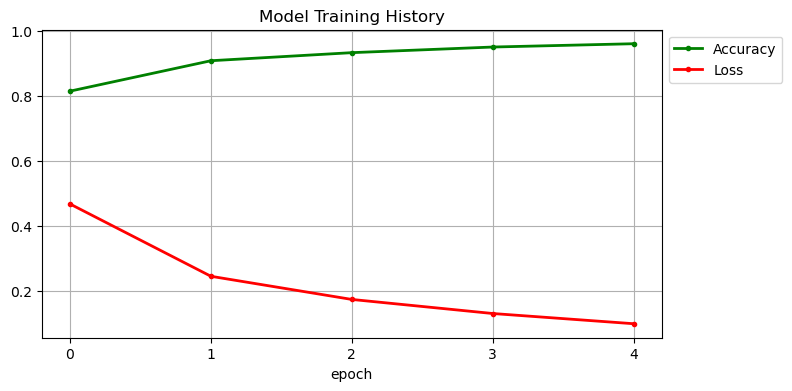

In [8]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = load_images_clean(test_paths)  # Load and normalize test images (no augmentation)
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 866ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       400
           1       0.87      0.94      0.90       400
           2       0.91      1.00      0.95       400
           3       0.94      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



Confusion Matrix:
[[302  55  33  10]
 [  3 377   6  14]
 [  0   0 400   0]
 [  0   3   1 396]]


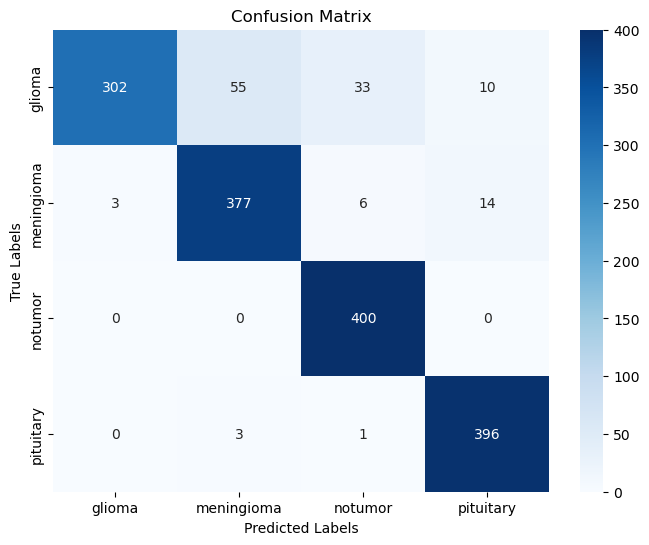

In [10]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

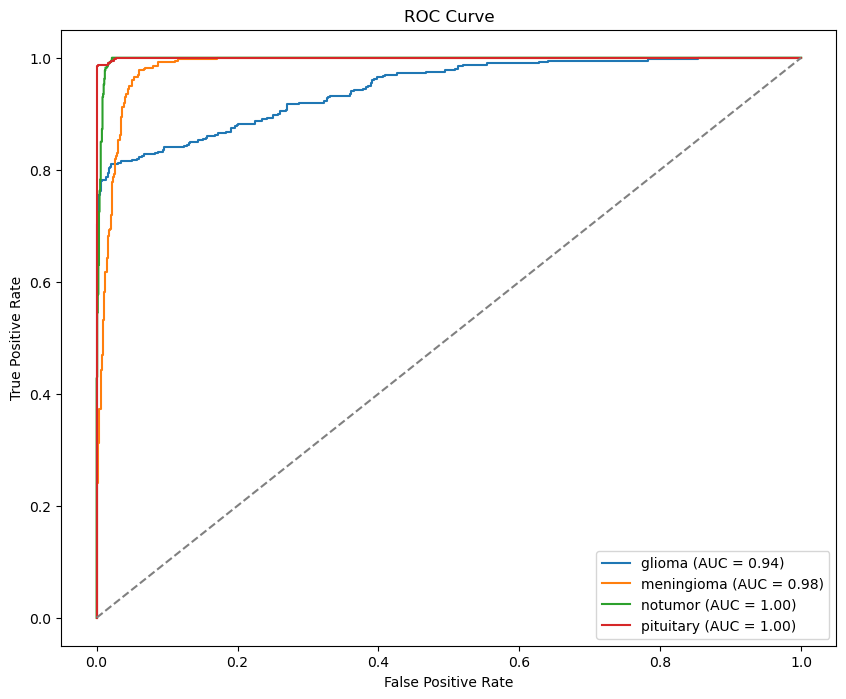

In [11]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(unique_labels)))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(unique_labels)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(unique_labels)):
    plt.plot(fpr[i], tpr[i], label=f'{unique_labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [12]:
# Save the entire model
model.save('model.keras')

In [13]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.keras')

In [14]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        predicted_label = unique_labels[predicted_class_index]
        if predicted_label == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_label}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


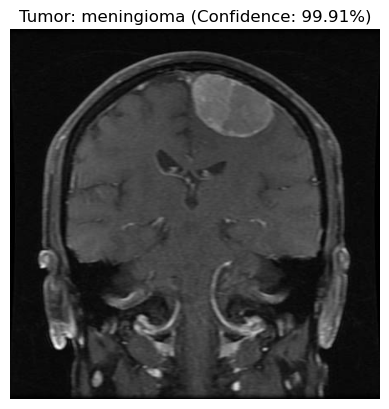

In [15]:
image_path = 'MRI Images/testing/meningioma/Te-me_1.jpg'  # note: lowercase 'testing', and real filename
detect_and_display(image_path, model)

MRI Images/testing\notumor\Te-no_360.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


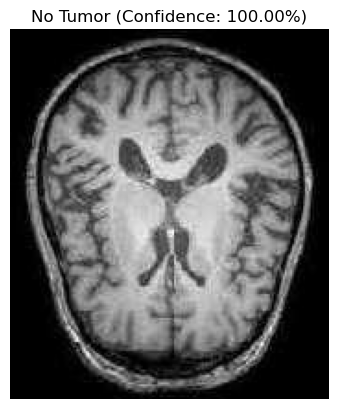

In [16]:

# Example usage
image_path = next(p for p in test_paths if 'notumor' in p)
print(image_path)
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


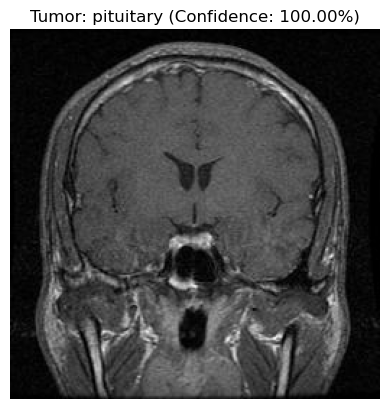

In [17]:
# Example usage
image_path = 'MRI Images/testing/pituitary/Te-pi_96.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


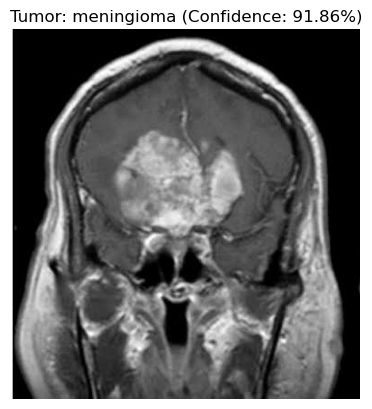

In [23]:
# Example usage
image_path = 'MRI Images/Testing/glioma/Te-gl_15.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


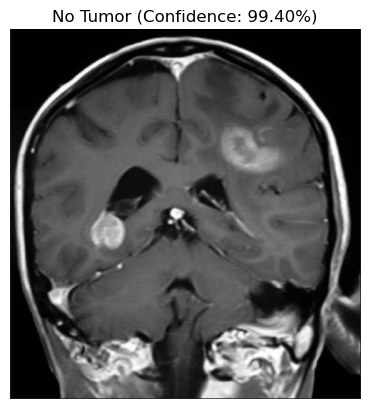

In [24]:

# Example usage
image_path = 'MRI Images/Testing/glioma/Te-gl_27.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


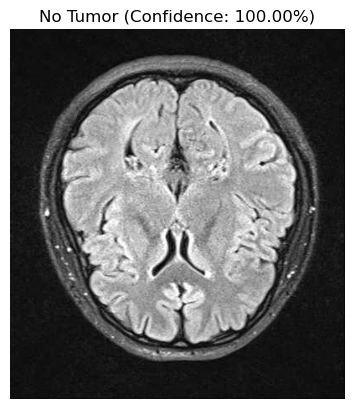

In [20]:
# Option 1: forward slashes (recommended, matches the rest of your code)
image_path = 'MRI Images/testing/notumor/Te-no_34.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


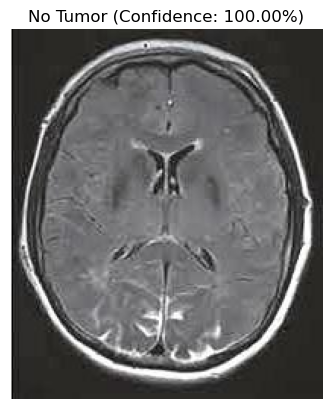

In [21]:
image_path = 'MRI Images/testing/notumor/Te-no_45.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


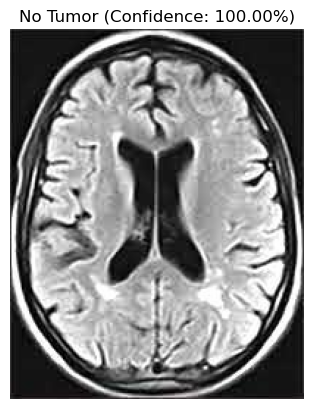

In [22]:
#Te-no_41
image_path = 'MRI Images/testing/notumor/Te-no_41.jpg'
detect_and_display(image_path, model)